In [2]:
import os
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt
import optuna

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Load Data

In [5]:
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2 , contrast = 0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean =[0.485 , 0.456 , 0.406] , std =[0.229 , 0.224 , 0.225])  # from imagenet
])

In [6]:
dataset_path = "./dataset"

dataset = datasets.ImageFolder(dataset_path , transform = image_transforms)
len(dataset)

2300

In [7]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [8]:
num_classes = len(dataset.classes)
num_classes

6

In [9]:
train_size = int(0.75 * len(dataset))
val_size = len(dataset) - train_size
train_size , val_size

(1725, 575)

In [10]:
from torch.utils.data import random_split

train_dataset , val_dataset = random_split(dataset , [train_size , val_size])

In [11]:
train_loader = DataLoader(train_dataset , batch_size=32 , shuffle = True)
val_loader = DataLoader(val_dataset , batch_size=32 , shuffle=True)

In [12]:
for images , labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [13]:
labels[0]

tensor(3)

In [14]:
images[0].shape

torch.Size([3, 224, 224])

In [15]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3959913].


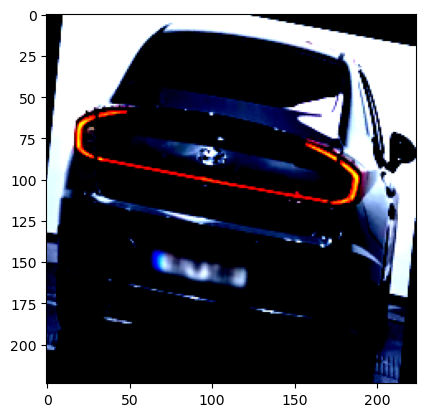

In [16]:
plt.imshow(images[20].permute(1,2,0))
plt.show()

### Model 1 : CNN

In [16]:
class CarClassifierCNN(nn.Module):
    def __init__(self , num_classes):
        super().__init__()
        self.network = nn.Sequential(   
            nn.Conv2d(in_channels=3, out_channels = 16 ,kernel_size = 3 ,stride= 1 ,padding =1), # in (3,224,224) out - (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (16 , 112,112),

            nn.Conv2d(in_channels=16, out_channels = 32 ,kernel_size = 3 ,stride= 1 ,padding =1), # in (16,112,112) out - (32 ,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (32,56,56)

            nn.Conv2d(in_channels=32, out_channels = 64 ,kernel_size = 3 ,stride= 1 ,padding =1) ,# in (32,56,56) out - (64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (64 ,28,28),
            
            nn.Flatten(),
            nn.Linear(64*28*28 , 512),
            nn.ReLU(),
            nn.Linear(512 , num_classes),
        )

    def forward(self,x):
        x = self.network(x)
        return x
        

In [17]:
model = CarClassifierCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001)

In [18]:
len(train_loader) #number of batches , len(train_loader.dataset) # number of images

54

In [22]:
def train_model(model , criterion , optimizer , epochs = 5):
    start = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num , (images , labels) in enumerate(train_loader):
            images , labels = images.to(device) , labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            #forward pass
            outputs = model(images)
            loss = criterion(outputs , labels)
            
            #backword pass and optimizer
            loss.backward()
            optimizer.step()

            if (batch_num+1) % 10 == 0:
                print(f"Batch : {batch_num+1} , Epoch: {epoch+1} , Loss: {loss.item(): 0.2f}")

            running_loss += loss.item() * images.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}] , Avg loss: {epoch_loss: .4f}")

        # validation
        model.eval()
        correct=0
        total=0
        all_labels = []
        all_predictions =[]

        with torch.no_grad():
            for images , labels in val_loader:
                images , labels = images.to(device) , labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data,1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())
            print(f"*** Validation Accuracy : {100 * correct / total:.2f}% ***")
    end = time.time()
    print(f"Execution time : {end-start} seconds")
    return all_labels , all_predictions      

In [20]:
labels , predictions = train_model(model , criterion , optimizer , epochs =10)

Batch : 10 , Epoch: 1 , Loss:  1.82
Batch : 20 , Epoch: 1 , Loss:  1.66
Batch : 30 , Epoch: 1 , Loss:  1.64
Batch : 40 , Epoch: 1 , Loss:  1.60
Batch : 50 , Epoch: 1 , Loss:  1.10
Epoch [1/10] , Avg loss:  1.7683
*** Validation Accuracy : 46.43% ***
Batch : 10 , Epoch: 2 , Loss:  1.47
Batch : 20 , Epoch: 2 , Loss:  1.25
Batch : 30 , Epoch: 2 , Loss:  1.31
Batch : 40 , Epoch: 2 , Loss:  1.28
Batch : 50 , Epoch: 2 , Loss:  1.50
Epoch [2/10] , Avg loss:  1.2379
*** Validation Accuracy : 48.52% ***
Batch : 10 , Epoch: 3 , Loss:  1.12
Batch : 20 , Epoch: 3 , Loss:  1.37
Batch : 30 , Epoch: 3 , Loss:  0.96
Batch : 40 , Epoch: 3 , Loss:  1.09
Batch : 50 , Epoch: 3 , Loss:  0.98
Epoch [3/10] , Avg loss:  1.0915
*** Validation Accuracy : 47.30% ***
Batch : 10 , Epoch: 4 , Loss:  1.30
Batch : 20 , Epoch: 4 , Loss:  0.95
Batch : 30 , Epoch: 4 , Loss:  1.14
Batch : 40 , Epoch: 4 , Loss:  1.00
Batch : 50 , Epoch: 4 , Loss:  0.94
Epoch [4/10] , Avg loss:  0.9941
*** Validation Accuracy : 50.09% ***


### Model 2 : CNN with Regularization

In [ ]:
class CarClassifierCNNWithRegularization(nn.Module):
    def __init__(self , num_classes):
        super().__init__()
        self.network = nn.Sequential(   
            nn.Conv2d(in_channels=3, out_channels = 16 ,kernel_size = 3 ,stride= 1 ,padding =1), # in (3,224,224) out - (16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (16 , 112,112),

            nn.Conv2d(in_channels=16, out_channels = 32 ,kernel_size = 3 ,stride= 1 ,padding =1), # in (16,112,112) out - (32 ,112,112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (32,56,56)

            nn.Conv2d(in_channels=32, out_channels = 64 ,kernel_size = 3 ,stride= 1 ,padding =1) ,# in (32,56,56) out - (64,56,56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # out (64 ,28,28),
            
            nn.Flatten(),
            nn.Linear(64*28*28 , 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512 , num_classes),
        )

    def forward(self,x):
        x = self.network(x)
        return x
        

In [ ]:
model = CarClassifierCNNWithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters() , lr = 0.001)

labels , predictions = train_model(model , criterion , optimizer , epochs =10)


### Model 4: Trnasfer learning with ResNet

In [35]:
model = models.resnet50(weights="DEFAULT")
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [40]:
class ClassifierRestNet(nn.Module):
    def __init__(self , num_classes):
        super().__init__()
        self.model = models.resnet50(weights = "DEFAULT")
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        #replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features , num_classes)
        )
    def forward(self,x):
        x = self.model(x)
        return x

In [41]:
model = ClassifierRestNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p:p.requires_grad , model.parameters()) , lr =0.001)
 
labels , predictions = train_model(model , criterion , optimizer , epochs =10)

Batch : 10 , Epoch: 1 , Loss:  1.10
Batch : 20 , Epoch: 1 , Loss:  0.85
Batch : 30 , Epoch: 1 , Loss:  0.50
Batch : 40 , Epoch: 1 , Loss:  0.61
Batch : 50 , Epoch: 1 , Loss:  0.76
Epoch [1/10] , Avg loss:  0.8591
*** Validation Accuracy : 73.91% ***
Batch : 10 , Epoch: 2 , Loss:  0.64
Batch : 20 , Epoch: 2 , Loss:  0.46
Batch : 30 , Epoch: 2 , Loss:  0.42
Batch : 40 , Epoch: 2 , Loss:  0.55
Batch : 50 , Epoch: 2 , Loss:  0.30
Epoch [2/10] , Avg loss:  0.4893
*** Validation Accuracy : 75.30% ***
Batch : 10 , Epoch: 3 , Loss:  0.24
Batch : 20 , Epoch: 3 , Loss:  0.16
Batch : 30 , Epoch: 3 , Loss:  0.31
Batch : 40 , Epoch: 3 , Loss:  0.56
Batch : 50 , Epoch: 3 , Loss:  0.22
Epoch [3/10] , Avg loss:  0.3210
*** Validation Accuracy : 77.74% ***
Batch : 10 , Epoch: 4 , Loss:  0.30
Batch : 20 , Epoch: 4 , Loss:  0.30
Batch : 30 , Epoch: 4 , Loss:  0.19
Batch : 40 , Epoch: 4 , Loss:  0.15
Batch : 50 , Epoch: 4 , Loss:  0.13
Epoch [4/10] , Avg loss:  0.2506
*** Validation Accuracy : 78.43% ***


### Hyperparameter Tunning : Resnet

In [17]:
class CarClassifierRestNet(nn.Module):
    def __init__(self , num_classes , dropout_rate = 0.5):
        super().__init__()
        self.model = models.resnet50(weights = "DEFAULT")
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        #replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features , num_classes)
        )
    def forward(self,x):
        x = self.model(x)
        return x

In [18]:
# define objective function for optuna
def objective(trial):
    # Suggest values for the hyperparameters
    lr = trial.suggest_float('lr' , 1e-5 , 1e-2 , log=True)
    dropout_rate = trial.suggest_float('dropout_rate' , 0.2 , 0.7)

    # load the model
    model = CarClassifierRestNet(num_classes = num_classes , dropout_rate=dropout_rate).to(device)

    #difine the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad , model.parameters()), lr = lr)

    # Training loop
    epochs = 3
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num ,(images , labels) in enumerate(train_loader):
            images, labels = images.to(device) , labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs , labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)

        # Validation loop
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images , labels in val_loader:
                images , labels = images.to(device) , labels.to(device)
                outputs = model(images)
                _,predicted = torch.max(outputs.data , 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct/total
        
        # report imidiate results to optuna
        trial.report(accuracy , epoch)

        # Handle pruning (if applicable)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    end = time.time()
    print(f"Execution time : {end-start} seconds")

    return accuracy
        
                

In [19]:
#create the study and optimize
study = optuna.create_study(direction ='maximize') 
study.optimize(objective , n_trials=20)

[I 2025-12-28 21:35:40,757] A new study created in memory with name: no-name-ba6ad49a-ad82-4152-9a63-f23e0b79bcc7
[I 2025-12-28 22:01:28,978] Trial 0 finished with value: 77.91304347826087 and parameters: {'lr': 0.003088649715305355, 'dropout_rate': 0.38398047077781683}. Best is trial 0 with value: 77.91304347826087.


Execution time : 1547.5310394763947 seconds


[I 2025-12-28 22:28:05,756] Trial 1 finished with value: 57.91304347826087 and parameters: {'lr': 1.9858801875503855e-05, 'dropout_rate': 0.32401120784050785}. Best is trial 0 with value: 77.91304347826087.


Execution time : 1595.2447381019592 seconds


[I 2025-12-28 22:54:16,599] Trial 2 finished with value: 78.6086956521739 and parameters: {'lr': 0.0007279329997789452, 'dropout_rate': 0.21681623818855583}. Best is trial 2 with value: 78.6086956521739.


...

[I 2025-12-28 23:56:04,988] Trial 5 pruned. 
[I 2025-12-29 00:04:54,363] Trial 6 pruned. 
[I 2025-12-29 00:27:04,383] Trial 7 finished with value: 78.6086956521739 and parameters: {'lr': 0.0007310785494782178, 'dropout_rate': 0.33002934612512425}. Best is trial 2 with value: 78.6086956521739.


Execution time : 1329.2607452869415 seconds


[I 2025-12-29 00:35:16,858] Trial 8 pruned. 
[I 2025-12-29 00:46:28,839] Trial 9 pruned. 
[I 2025-12-29 00:53:58,188] Trial 10 pruned. 
[I 2025-12-29 01:19:40,355] Trial 11 finished with value: 78.26086956521739 and parameters: {'lr': 0.0007956261249828812, 'dropout_rate': 0.4914015286968153}. Best is trial 2 with value: 78.6086956521739.


Execution time : 1541.505916595459 seconds


[I 2025-12-29 01:27:50,124] Trial 12 pruned. 
[I 2025-12-29 01:35:19,808] Trial 13 pruned. 
[I 2025-12-29 01:42:49,758] Trial 14 pruned. 
[I 2025-12-29 01:50:18,621] Trial 15 pruned. 
[I 2025-12-29 01:57:49,376] Trial 16 pruned. 
[I 2025-12-29 02:05:12,491] Trial 17 pruned. 
[I 2025-12-29 02:12:41,073] Trial 18 pruned. 
[I 2025-12-29 02:20:01,899] Trial 19 pruned. 


In [20]:
best_params = study.best_params
print(best_params)

{'lr': 0.0007279329997789452, 'dropout_rate': 0.21681623818855583}


In [23]:
model = CarClassifierRestNet(num_classes=num_classes , dropout_rate=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p:p.requires_grad , model.parameters()) , lr =0.0007)
 
labels , predictions = train_model(model , criterion , optimizer , epochs =10)

Batch : 10 , Epoch: 1 , Loss:  1.19
Batch : 20 , Epoch: 1 , Loss:  0.81
Batch : 30 , Epoch: 1 , Loss:  0.69
Batch : 40 , Epoch: 1 , Loss:  0.58
Batch : 50 , Epoch: 1 , Loss:  0.61
Epoch [1/10] , Avg loss:  0.9046
*** Validation Accuracy : 73.74% ***
Batch : 10 , Epoch: 2 , Loss:  0.50
Batch : 20 , Epoch: 2 , Loss:  0.47
Batch : 30 , Epoch: 2 , Loss:  0.35
Batch : 40 , Epoch: 2 , Loss:  0.54
Batch : 50 , Epoch: 2 , Loss:  0.31
Epoch [2/10] , Avg loss:  0.4573
*** Validation Accuracy : 75.65% ***
Batch : 10 , Epoch: 3 , Loss:  0.76
Batch : 20 , Epoch: 3 , Loss:  0.42
Batch : 30 , Epoch: 3 , Loss:  0.20
Batch : 40 , Epoch: 3 , Loss:  0.14
Batch : 50 , Epoch: 3 , Loss:  0.30
Epoch [3/10] , Avg loss:  0.3296
*** Validation Accuracy : 73.74% ***
Batch : 10 , Epoch: 4 , Loss:  0.18
Batch : 20 , Epoch: 4 , Loss:  0.05
Batch : 30 , Epoch: 4 , Loss:  0.52
Batch : 40 , Epoch: 4 , Loss:  0.20
Batch : 50 , Epoch: 4 , Loss:  0.24
Epoch [4/10] , Avg loss:  0.2488
*** Validation Accuracy : 79.48% ***


### Model Evaluation using Confusion Matrix and Classification Report

In [24]:
from sklearn.metrics import classification_report

report = classification_report(labels , predictions)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.81      0.85       108
           1       0.79      0.87      0.83       106
           2       0.89      0.89      0.89       125
           3       0.82      0.69      0.75        80
           4       0.68      0.76      0.72        75
           5       0.84      0.86      0.85        81

    accuracy                           0.82       575
   macro avg       0.82      0.81      0.81       575
weighted avg       0.83      0.82      0.82       575



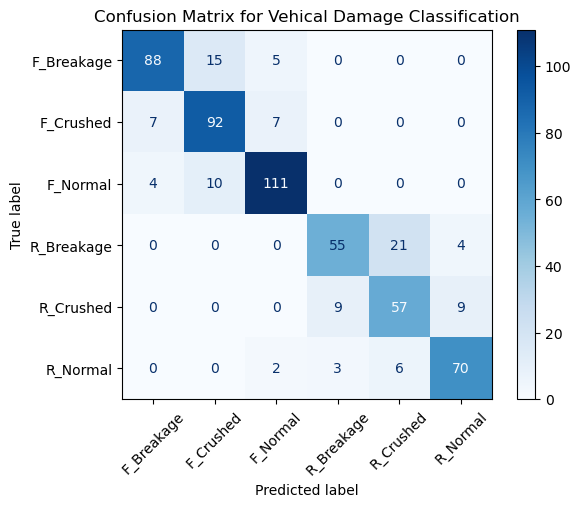

In [25]:
import numpy as np 
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels , predictions , labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix = conf_matrix , display_labels = dataset.classes)
disp.plot(cmap =plt.cm.Blues , xticks_rotation = 45)
plt.title("Confusion Matrix for Vehical Damage Classification")
plt.show()

In [27]:
torch.save(model.state_dict() , 'saved_model_resnet_finalized.pth')